#GAN Ship & Helicopter Class
Almayra Edgina Rahma

#Link Video: https://youtu.be/r1BNcuxCO08

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from scipy.linalg import sqrtm
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from google.colab import drive



# Load Data

In [2]:
train_path="/content/drive/MyDrive/GAN_Ship&Heli/train"
test_path="/content/drive/MyDrive/GAN_Ship&Heli/test"

classes={"ship":0,"helicopter":1}
half_batch=batch_size//2

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
def load_dataset(path, classes, img_size=(28,28)):
    images, labels = [], []
    for cls, lab in classes.items():
        folder=os.path.join(path, cls)
        for f in os.listdir(folder):
            img=cv2.imread(os.path.join(folder,f), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img=cv2.resize(img,img_size).astype(np.float32)/255.0
            images.append(img)
            labels.append(lab)
    return np.array(images).reshape(-1,*img_size,1), np.array(labels)

trainX,trainY=load_dataset(train_path,classes)
testX,testY=load_dataset(test_path,classes)
print(trainX.shape,testX.shape)


(1544, 28, 28, 1) (193, 28, 28, 1)


#Baseline

In [5]:
noise_dim = 50
num_classes = 2
batch_size = 64
epochs = 200

## Generator

In [6]:
noise = layers.Input(shape=(noise_dim,))
label = layers.Input(shape=(1,), dtype='int32')

emb = layers.Embedding(num_classes, 50)(label)
emb = layers.Flatten()(emb)

x = layers.Concatenate()([noise, emb])

for units in [128, 256, 512, 1024]:
    x = layers.Dense(units)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

x = layers.Dense(28*28, activation='sigmoid')(x)
out = layers.Reshape((28,28,1))(x)

generator = Model([noise, label], out)
generator.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        100 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     33,024 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 256)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    131,584 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 512)       │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024)      │    525,312 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 1024)      │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 784)       │    803,600 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,506,548 (5.75 MB)

 Trainable params: 1,506,548 (5.75 MB)

 Non-trainable params: 0 (0.00 B)

## Discriminator

In [7]:
image = layers.Input(shape=(28,28,1))
label = layers.Input(shape=(1,), dtype='int32')
img = layers.Flatten()(image)
lbl = layers.Flatten()(layers.Embedding(num_classes, 28*28)(label))

x = layers.Concatenate()([img, lbl])

for units in [512, 1024, 1024, 512]:
    x = layers.Dense(units)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

out = layers.Dense(1, activation='sigmoid')(x)

discriminator = Model([image, label], out)
discriminator.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 784)    │      1,568 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 784)       │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1568)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    803,328 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 512)       │          0 │ dense_5[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024)      │    525,312 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 1024)      │          0 │ dense_6[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1024)      │  1,049,600 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 1024)      │          0 │ dense_7[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │    524,800 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 512)       │          0 │ dense_8[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │        513 │ leaky_re_lu_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,905,121 (11.08 MB)

 Trainable params: 2,905,121 (11.08 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

discriminator.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

discriminator.trainable = False
noise = layers.Input(shape=(noise_dim,))
label = layers.Input(shape=(1,), dtype='int32')

generated_image = generator([noise, label])
validity = discriminator([generated_image, label])

gan = Model([noise, label], validity)
gan.compile(optimizer=Adam(learning_rate=0.0002, beta_1=0.5),loss='binary_crossentropy')

## Image generator

In [9]:
def get_real_samples(bs):
    idx=np.random.randint(0,len(trainX),bs)
    return trainX[idx], trainY[idx].reshape(-1,1)

def get_fake_samples(bs):
    z=np.random.normal(0,1,(bs,noise_dim))
    lbl=np.random.randint(0,num_classes,(bs,1))
    imgs=generator.predict([z,lbl],verbose=0)
    return imgs,lbl

##Compiling

In [10]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002,beta_1=0.5)

In [11]:
discriminator.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])
gan.compile(optimizer=optimizer,loss='binary_crossentropy')

In [12]:
epochs=200
losses_d = []
losses_g = []
batch_size = 64

half_batch = batch_size // 2

for epoch in range(epochs):

    real_images, real_labels = get_real_samples(half_batch)
    real_y = np.ones((half_batch, 1))

    d_loss_real = discriminator.train_on_batch([real_images, real_labels],real_y)

    noise = np.random.normal(0, 1, (half_batch, noise_dim))

    fake_images, fake_labels = get_fake_samples(half_batch)
    fake_y = np.zeros((half_batch,1))

    d_loss_fake = discriminator.train_on_batch([fake_images, fake_labels], fake_y)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    noise = np.random.normal(0,1,(batch_size,noise_dim))

    sampled_labels = np.random.randint(0, num_classes,(batch_size,1))

    valid_y = np.ones((batch_size,1))

    discriminator.trainable = False

    g_loss = gan.train_on_batch([noise, sampled_labels],valid_y)

    discriminator.trainable = True

    losses_d.append(d_loss[0])
    losses_g.append(g_loss)

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch}/{epochs} | "
            f"D Loss: {d_loss[0]:.4f} | "
            f"D Acc: {d_loss[1]*100:.2f}% | "
            f"G Loss: {g_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0/200 | D Loss: 0.6372 | D Acc: 75.00% | G Loss: 0.6061
Epoch 10/200 | D Loss: 0.7433 | D Acc: 51.19% | G Loss: 0.5172
Epoch 20/200 | D Loss: 0.9397 | D Acc: 50.61% | G Loss: 0.3678
Epoch 30/200 | D Loss: 1.1733 | D Acc: 50.41% | G Loss: 0.2711
Epoch 40/200 | D Loss: 1.3358 | D Acc: 50.27% | G Loss: 0.2163
Epoch 50/200 | D Loss: 1.4481 | D Acc: 50.19% | G Loss: 0.1818
Epoch 60/200 | D Loss: 1.5307 | D Acc: 50.16% | G Loss: 0.1581
Epoch 70/200 | D Loss: 1.5938 | D Acc: 50.11% | G Loss: 0.1408
Epoch 80/200 | D Loss: 1.6428 | D Acc: 50.10% | G Loss: 0.1276
Epoch 90/200 | D Loss: 1.6822 | D Acc: 50.07% | G Loss: 0.1173
Epoch 100/200 | D Loss: 1.7144 | D Acc: 50.05% | G Loss: 0.1089
Epoch 110/200 | D Loss: 1.7415 | D Acc: 50.04% | G Loss: 0.1021
Epoch 120/200 | D Loss: 1.7644 | D Acc: 50.04% | G Loss: 0.0963
Epoch 130/200 | D Loss: 1.7841 | D Acc: 50.04% | G Loss: 0.0914
Epoch 140/200 | D Loss: 1.8012 | D Acc: 50.03% | G Loss: 0.0872
Epoch 150/200 | D Loss: 1.8161 | D Acc: 50.03% | G 

In [13]:
num_test = len(testX)

noise = np.random.normal(0, 1, (num_test, noise_dim))
labels = np.random.randint(0, 2, (num_test,1))

fake_images = generator.predict([noise, labels], verbose=0)

print(fake_images.shape)
print(testX.shape)

(193, 28, 28, 1)
(193, 28, 28, 1)


##Evaluation

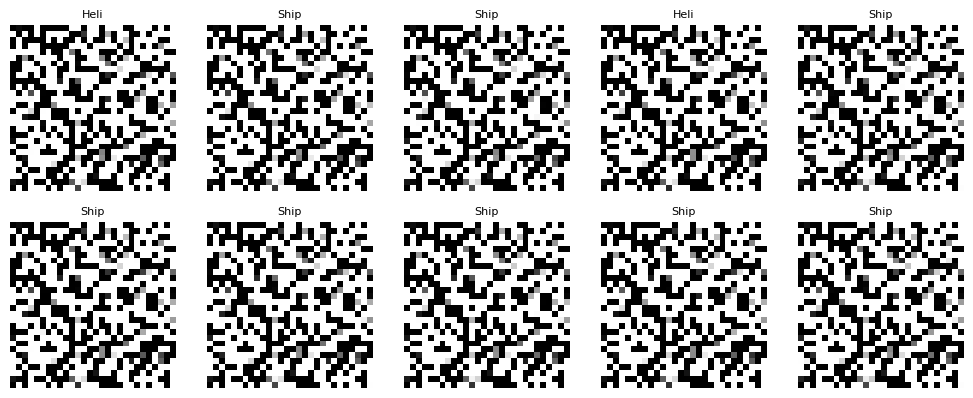

In [14]:
plt.figure(figsize=(10,10))

for i in range(10):

    plt.subplot(5,5,i+1)
    plt.imshow(fake_images[i].squeeze(), cmap="gray")
    plt.title("Ship" if labels[i]==0 else "Heli", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

### menggunakan InceptionV3 untuk mengkalkulasi FID

In [15]:
model = InceptionV3(include_top=False,pooling='avg',input_shape=(299,299,3))

In [16]:
real = tf.convert_to_tensor(testX, dtype=tf.float32)
fake = tf.convert_to_tensor(fake_images, dtype=tf.float32)

real = tf.image.grayscale_to_rgb(real)
fake = tf.image.grayscale_to_rgb(fake)

real = tf.image.resize(real, (299, 299))
fake = tf.image.resize(fake, (299, 299))

real_features = model.predict(real, verbose=0)
fake_features = model.predict(fake, verbose=0)

mu_real = np.mean(real_features, axis=0)
mu_fake = np.mean(fake_features, axis=0)

sigma_real = np.cov(real_features, rowvar=False)
sigma_fake = np.cov(fake_features, rowvar=False)

covmean = sqrtm(sigma_real.dot(sigma_fake))

if np.iscomplexobj(covmean):
    covmean = covmean.real

fid = np.sum((mu_real - mu_fake) ** 2) + np.trace(
    sigma_real + sigma_fake - 2 * covmean)

print("FID:", fid)

FID: 728.0181596927398


/tmp/ipykernel_33841/589122698.py:19: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma_real.dot(sigma_fake))


#Modified

## Generator

In [17]:
noise=layers.Input(shape=(noise_dim,))
label=layers.Input(shape=(1,),dtype='int32')

emb=layers.Embedding(num_classes,noise_dim)(label)
emb=layers.Flatten()(emb)

x=layers.Concatenate()([noise,emb])
x=layers.Dense(7*7*128,use_bias=False)(x)
x=layers.BatchNormalization()(x)
x=layers.LeakyReLU(0.2)(x)
x=layers.Reshape((7,7,128))(x)

for f in [64,32]:
    x=layers.Conv2DTranspose(f,4,2,padding="same",use_bias=False)(x)
    x=layers.BatchNormalization()(x)
    x=layers.LeakyReLU(0.2)(x)

out=layers.Conv2D(1,3,padding="same",activation="sigmoid")(x)
generator=Model([noise,label],out)
generator.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 50)     │        100 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 50)        │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 100)       │          0 │ input_layer_7[0]… │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 6272)      │    627,200 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6272)      │     25,088 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 6272)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │    131,072 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28,    │     32,768 │ leaky_re_lu_9[0]… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 28, 28, 1) │        289 │ leaky_re_lu_10[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 816,901 (3.12 MB)

 Trainable params: 804,165 (3.07 MB)

 Non-trainable params: 12,736 (49.75 KB)

## Discriminator

In [18]:
image=layers.Input(shape=(28,28,1))
label=layers.Input(shape=(1,),dtype='int32')

emb=layers.Embedding(num_classes,28*28)(label)
emb=layers.Flatten()(emb)
emb=layers.Reshape((28,28,1))(emb)

x=layers.Concatenate()([image,emb])

for f in [64,128]:
    x=layers.Conv2D(f,4,2,padding='same')(x)
    x=layers.LeakyReLU(0.2)(x)
    x=layers.Dropout(0.3)(x)

x=layers.Flatten()(x)
x=layers.Dense(256)(x)
x=layers.LeakyReLU(0.2)(x)
x=layers.Dropout(0.3)(x)

out=layers.Dense(1,activation='sigmoid')(x)
discriminator=Model([image,label],out)
discriminator.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 784)    │      1,568 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 784)       │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 28, 28, 1) │          0 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 28, 28, 2) │          0 │ input_layer_9[0]… │
│ (Concatenate)       │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 14, 14,    │      2,112 │ concatenate_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 14, 14,    │          0 │ conv2d_95[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ leaky_re_lu_11[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 7, 7, 128) │    131,200 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 7, 7, 128) │          0 │ conv2d_96[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 6272)      │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 256)       │  1,605,888 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 256)       │          0 │ dense_11[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │        257 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,741,025 (6.64 MB)

 Trainable params: 1,741,025 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [19]:
optimizer=Adam(1e-4,beta_1=0.5)
discriminator.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])
discriminator.trainable=False

z=layers.Input(shape=(noise_dim,))
lbl=layers.Input(shape=(1,),dtype='int32')
valid=discriminator([generator([z,lbl]),lbl])

gan=Model([z,lbl],valid)
gan.compile(optimizer=Adam(1e-4,beta_1=0.5),loss='binary_crossentropy')

discriminator.trainable=True

In [20]:
epochs=800

In [21]:
loss_d = []
loss_g = []

for epoch in range(epochs):

    real_x, real_lbl = get_real_samples(half_batch)
    fake_x, fake_lbl = get_fake_samples(half_batch)
    real_y = np.ones((half_batch, 1)) * 0.9
    fake_y = np.zeros((half_batch, 1))

    discriminator.trainable = True

    if np.random.rand() < 0.5:
        d1 = discriminator.train_on_batch([real_x, real_lbl], real_y)
        d2 = discriminator.train_on_batch([fake_x, fake_lbl], fake_y)
    else:
        d2 = discriminator.train_on_batch([fake_x, fake_lbl], fake_y)
        d1 = discriminator.train_on_batch([real_x, real_lbl], real_y)

    d = 0.5 * np.add(d1, d2)

    z = np.random.normal(0, 1, (batch_size, noise_dim))
    lbl = np.random.randint(0, num_classes, (batch_size, 1))

    discriminator.trainable = False

    g = gan.train_on_batch([z, lbl],np.ones((batch_size, 1)))

    discriminator.trainable = True

    loss_d.append(d[0])
    loss_g.append(g)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"D Loss: {d[0]:.4f} | "
            f"D Acc: {d[1]*100:.2f}% | "
            f"G Loss: {g:.4f}")


Epoch    0 | D Loss: 0.7266 | D Acc: 30.47% | G Loss: 0.7439
Epoch   10 | D Loss: 0.7011 | D Acc: 36.36% | G Loss: 0.7083
Epoch   20 | D Loss: 0.6923 | D Acc: 37.51% | G Loss: 0.6806
Epoch   30 | D Loss: 0.6790 | D Acc: 39.18% | G Loss: 0.6369
Epoch   40 | D Loss: 0.6598 | D Acc: 40.88% | G Loss: 0.6089
Epoch   50 | D Loss: 0.6239 | D Acc: 42.67% | G Loss: 0.6594
Epoch   60 | D Loss: 0.5925 | D Acc: 43.88% | G Loss: 0.6437
Epoch   70 | D Loss: 0.5689 | D Acc: 44.39% | G Loss: 0.5607
Epoch   80 | D Loss: 0.5444 | D Acc: 45.40% | G Loss: 0.4958
Epoch   90 | D Loss: 0.5211 | D Acc: 45.90% | G Loss: 0.4438
Epoch  100 | D Loss: 0.4974 | D Acc: 46.31% | G Loss: 0.4079
Epoch  110 | D Loss: 0.4822 | D Acc: 46.63% | G Loss: 0.4380
Epoch  120 | D Loss: 0.4918 | D Acc: 46.13% | G Loss: 0.4862
Epoch  130 | D Loss: 0.4916 | D Acc: 45.89% | G Loss: 0.4536
Epoch  140 | D Loss: 0.4775 | D Acc: 46.36% | G Loss: 0.4266
Epoch  150 | D Loss: 0.4680 | D Acc: 46.39% | G Loss: 0.4630
Epoch  160 | D Loss: 0.4

In [22]:
num_test = len(testX)
noise = np.random.normal(0, 1, (num_test, noise_dim))
labels = np.random.randint(0, 2, (num_test,1))
fake_images = generator.predict([noise, labels], verbose=0)

print(fake_images.shape)
print(testX.shape)

(193, 28, 28, 1)
(193, 28, 28, 1)


## Evaluation

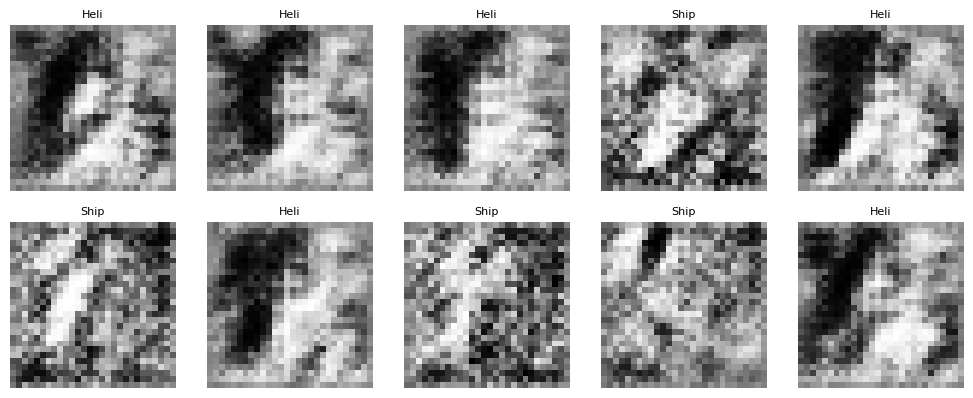

In [23]:
plt.figure(figsize=(10,10))

for i in range(10):

    plt.subplot(5,5,i+1)
    plt.imshow(fake_images[i].squeeze(), cmap="gray")
    plt.title("Ship" if labels[i]==0 else "Heli", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
model = InceptionV3(include_top=False,pooling='avg',input_shape=(299,299,3))

In [25]:
real = tf.convert_to_tensor(testX, dtype=tf.float32)
fake = tf.convert_to_tensor(fake_images, dtype=tf.float32)

real = tf.image.grayscale_to_rgb(real)
fake = tf.image.grayscale_to_rgb(fake)

real = tf.image.resize(real, (299, 299))
fake = tf.image.resize(fake, (299, 299))

In [26]:
real_features = model.predict(real, verbose=0)
fake_features = model.predict(fake, verbose=0)

In [27]:
mu_real = np.mean(real_features, axis=0)
mu_fake = np.mean(fake_features, axis=0)

sigma_real = np.cov(real_features, rowvar=False)
sigma_fake = np.cov(fake_features, rowvar=False)

covmean = sqrtm(sigma_real.dot(sigma_fake))

if np.iscomplexobj(covmean):
    covmean = covmean.real

fid2 = np.sum((mu_real - mu_fake) ** 2) + np.trace(
    sigma_real + sigma_fake - 2 * covmean)

print("FID:", fid2)

FID: 312.3934757172833


#Comparison

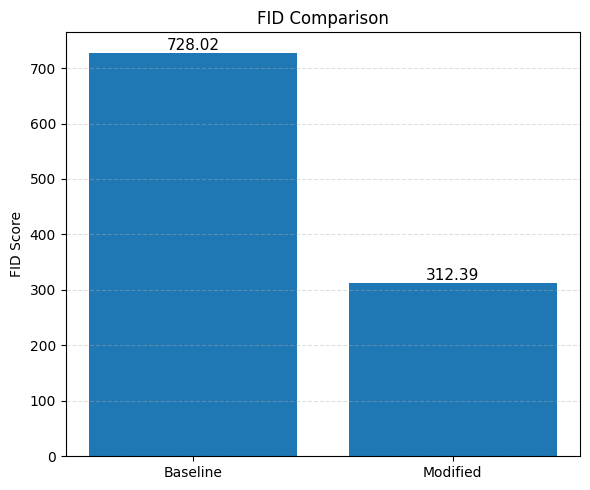

In [28]:
scores = [fid, fid2]
models = ["Baseline", "Modified"]

plt.figure(figsize=(6,5))
bars = plt.bar(models, scores)

plt.title("FID Comparison")
plt.ylabel("FID Score")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height,f"{height:.2f}",ha="center",va="bottom", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()